In [1]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

from torchvision.models import resnet18, ResNet18_Weights


print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cu126
torchvision: 0.25.0+cu126


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATASET_NAME = "CIFAR100"

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"
ARTIFACTS_DIR = "./artifacts/"
FIGURES_DIR = ARTIFACTS_DIR + "figures/"

EPOCHS_CNN = 5 if FAST_MODE else 15
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

Device: cpu


In [3]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

BATCH_SIZE_CNN = 128
BATCH_SIZE_RN = 64

IMG_SIZE = 224


# transforms
train_tf_cnn = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

eval_tf_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

train_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

eval_tf_resnet = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])


# load datasets
def load_cifar100_cnn(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_cnn)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_cnn)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_cnn)
    return ds_train_aug, ds_train_eval, ds_test

def load_cifar100_resnet(data_dir: str = DATA_DIR):
    ds_train_aug  = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=train_tf_resnet)
    ds_train_eval = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=eval_tf_resnet)
    ds_test = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=eval_tf_resnet)
    return ds_train_aug, ds_train_eval, ds_test


ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn = load_cifar100_cnn()
ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet = load_cifar100_resnet()

class_names = ds_train_eval_cnn.classes

100.0%


In [4]:
def make_loaders_cnn(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_CNN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


def make_loaders_no_aug(
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_CNN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE
):
    n_total = len(ds_train_eval)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    ds_train = Subset(ds_train_eval, indices[n_val:])
    ds_val = Subset(ds_train_eval, indices[:n_val])

    if fast_mode:
        ds_train = Subset(ds_train, rng.choice(len(ds_train), 4000, replace=False))
        ds_val = Subset(ds_val, rng.choice(len(ds_val), 1000, replace=False))
        ds_test = Subset(ds_test, rng.choice(len(ds_test), 1000, replace=False))

    return (DataLoader(ds_train, batch_size, shuffle=True, num_workers=8, pin_memory=True),
            DataLoader(ds_val, batch_size, shuffle=False, num_workers=8, pin_memory=True),
            DataLoader(ds_test, batch_size, shuffle=False, num_workers=8, pin_memory=True))


def make_loaders_resnet(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE_RN,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)

    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader_cnn, val_loader_cnn, test_loader_cnn = make_loaders_cnn(
    ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn,
    #fast_mode=True,
)

x, y = next(iter(train_loader_cnn))
print("CNN - x:", x.shape, x.dtype)
print("CNN - y:", y.shape, y.dtype)

train_loader_resnet, val_loader_resnet, test_loader_resnet = make_loaders_resnet(
    ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet,
    #fast_mode=True
)

x, y = next(iter(train_loader_resnet))
print("ResNet - x:", x.shape, x.dtype)
print("ResNet - y:", y.shape, y.dtype)

c:\Users\User\Desktop\al\artificial-intelligence\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


CNN - x: torch.Size([128, 3, 32, 32]) torch.float32
CNN - y: torch.Size([128]) torch.int64
ResNet - x: torch.Size([64, 3, 224, 224]) torch.float32
ResNet - y: torch.Size([64]) torch.int64


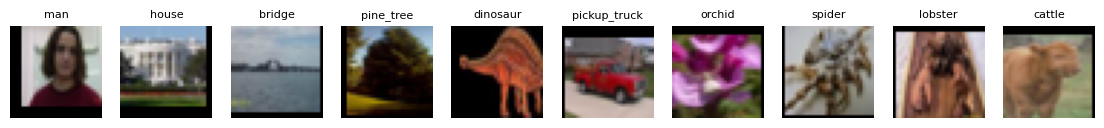

In [5]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(CIFAR100_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR100_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10, save_path=None) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")

    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()

save_path = os.path.join(FIGURES_DIR, "augmentations_preview.png")
show_images(train_loader_cnn, n=10, save_path=save_path)

In [6]:
INPUT_DIM = 32 * 32 * 3
NUM_CLASSES = 100

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# модель CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=100, bias=True)
  )
)
Trainable params: 643492


In [7]:
# обучение
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"optimizer": optimizer, "criterion": criterion, "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

# график
def plot_history(hist: Dict[str, List[float]], title: str = "", save_name: str = None) -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    if save_name:
        plt.savefig(os.path.join(FIGURES_DIR, save_name))
    plt.show()

In [8]:
criterion = nn.CrossEntropyLoss()

def run_experiment_cnn(exp_id: str, model: nn.Module, type_of_train_data: str, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = 5):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    if type_of_train_data == 'aug':
        train_loader, val_loader, _ = make_loaders_cnn(ds_train_aug_cnn, ds_train_eval_cnn, ds_test_cnn)
    else:
        train_loader, val_loader, _ = make_loaders_no_aug(ds_train_eval_cnn, ds_test_cnn)

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}

runs = [] # для runs.csv


Experiment C1 | lr=0.001 weight_decay=0.0 epochs=15
Trainable params: 643492
Epoch 01/15 | train loss 3.7804, acc 0.124 | val loss 3.3034, acc 0.199 | 112.4s
Epoch 02/15 | train loss 2.9881, acc 0.264 | val loss 2.8772, acc 0.282 | 111.9s
Epoch 03/15 | train loss 2.5883, acc 0.341 | val loss 2.5919, acc 0.344 | 113.1s
Epoch 04/15 | train loss 2.3219, acc 0.399 | val loss 2.4711, acc 0.370 | 111.9s
Epoch 05/15 | train loss 2.0966, acc 0.449 | val loss 2.3828, acc 0.385 | 112.4s
Epoch 06/15 | train loss 1.8984, acc 0.494 | val loss 2.3857, acc 0.398 | 111.1s
Epoch 07/15 | train loss 1.7094, acc 0.536 | val loss 2.4146, acc 0.400 | 113.5s
Epoch 08/15 | train loss 1.5465, acc 0.571 | val loss 2.4388, acc 0.400 | 112.6s
Epoch 09/15 | train loss 1.3817, acc 0.611 | val loss 2.5154, acc 0.403 | 113.6s
Epoch 10/15 | train loss 1.2206, acc 0.650 | val loss 2.6091, acc 0.402 | 107.6s
Epoch 11/15 | train loss 1.0720, acc 0.691 | val loss 2.7730, acc 0.392 | 92.8s
Epoch 12/15 | train loss 0.9441,

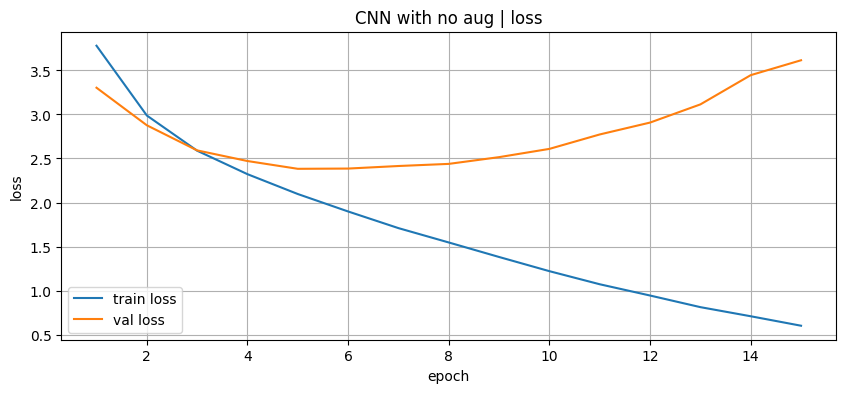

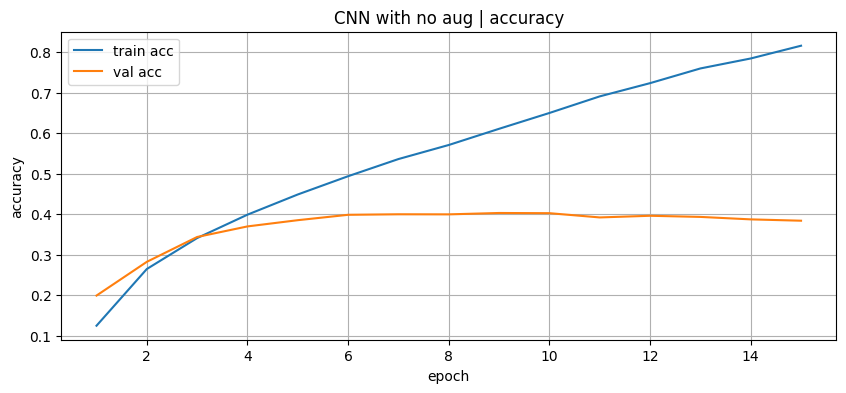

In [9]:
res_no_aug = run_experiment_cnn("C1", SimpleCNN(100), 'no_aug', epochs=EPOCHS_CNN)
plot_history(res_no_aug["history"], title="CNN with no aug")


Experiment C2 | lr=0.001 weight_decay=0.0 epochs=15
Trainable params: 643492
Epoch 01/15 | train loss 3.9486, acc 0.097 | val loss 3.4939, acc 0.170 | 93.9s
Epoch 02/15 | train loss 3.3366, acc 0.192 | val loss 3.1000, acc 0.241 | 92.9s
Epoch 03/15 | train loss 3.0338, acc 0.249 | val loss 2.8445, acc 0.284 | 95.9s
Epoch 04/15 | train loss 2.8224, acc 0.290 | val loss 2.6733, acc 0.323 | 97.7s
Epoch 05/15 | train loss 2.6608, acc 0.322 | val loss 2.5453, acc 0.352 | 96.3s
Epoch 06/15 | train loss 2.5390, acc 0.348 | val loss 2.4722, acc 0.363 | 96.9s
Epoch 07/15 | train loss 2.4296, acc 0.369 | val loss 2.3743, acc 0.384 | 97.2s
Epoch 08/15 | train loss 2.3376, acc 0.388 | val loss 2.3093, acc 0.403 | 96.6s
Epoch 09/15 | train loss 2.2655, acc 0.407 | val loss 2.3242, acc 0.395 | 96.4s
Epoch 10/15 | train loss 2.2030, acc 0.421 | val loss 2.2530, acc 0.411 | 100.4s
Epoch 11/15 | train loss 2.1339, acc 0.432 | val loss 2.2173, acc 0.417 | 97.4s
Epoch 12/15 | train loss 2.0899, acc 0.44

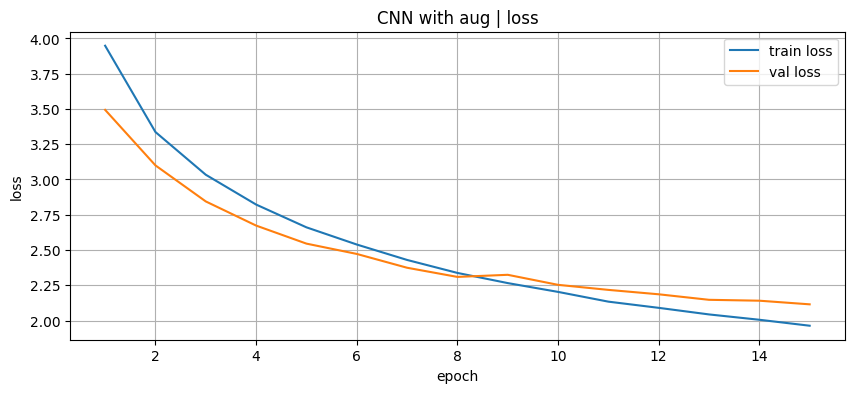

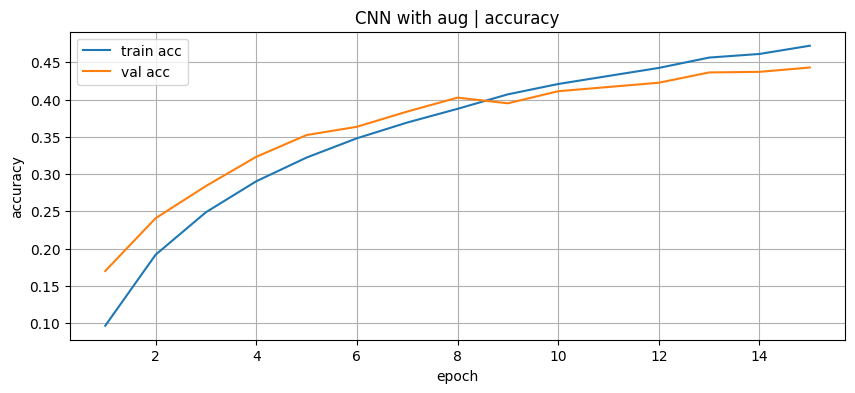

In [11]:

res_aug = run_experiment_cnn("C2", SimpleCNN(100), 'aug', epochs=EPOCHS_CNN)
plot_history(res_aug["history"], title="CNN with aug")

In [12]:
# часть ResNet

def get_resnet18_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet18_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


In [13]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# создание модели ResNet
def build_resnet18(num_classes: int, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model_resnet18 = build_resnet18(num_classes=NUM_CLASSES, weights=weights).to(DEVICE)
print(model_resnet18)
print("Trainable params:", count_trainable_params(model_resnet18))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
def run_experiment_resnet(exp_id: str, model: nn.Module, optimizer, epochs: int = 5):
    print("=" * 80)
    print(f"Experiment {exp_id}")
    print("Trainable params:", count_params(model))

    train_loader, val_loader, _ = make_loade
    
    rs_resnet(ds_train_aug_resnet, ds_train_eval_resnet, ds_test_resnet)
    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Phase 1: head-only training
Experiment C3
Trainable params: 51300
Epoch 01/1 | train loss 1.8562, acc 0.506 | val loss 1.8184, acc 0.514 | 1602.5s


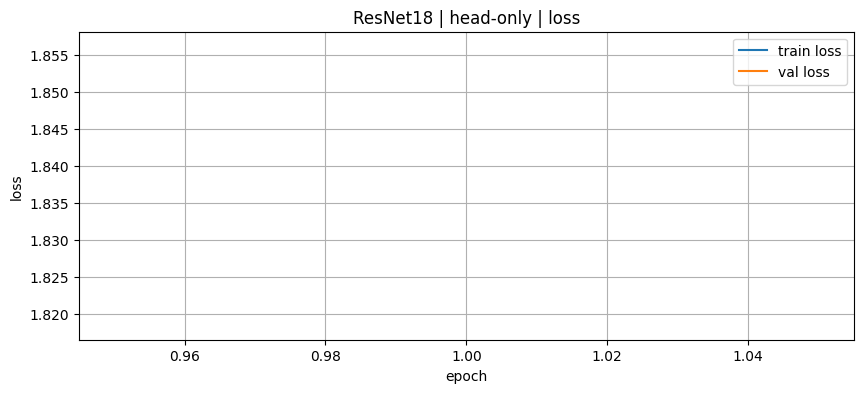

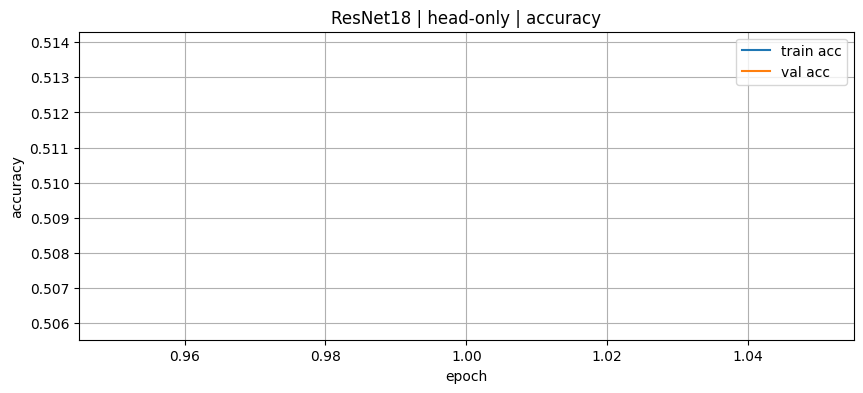

In [16]:
# freeze всё
set_requires_grad(model_resnet18, False)
# размораживаем только голову
set_requires_grad(model_resnet18.fc, True)

optimizer_head = torch.optim.Adam(model_resnet18.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = run_experiment_resnet("C3", model_resnet18, optimizer_head, epochs=1)
plot_history(hist_head["history"], title="ResNet18 | head-only")


Phase 2: fine-tuning layer4 + fc
Experiment C4
Trainable params: 8445028
Epoch 01/1 | train loss 1.4103, acc 0.598 | val loss 1.3051, acc 0.624 | 2170.3s


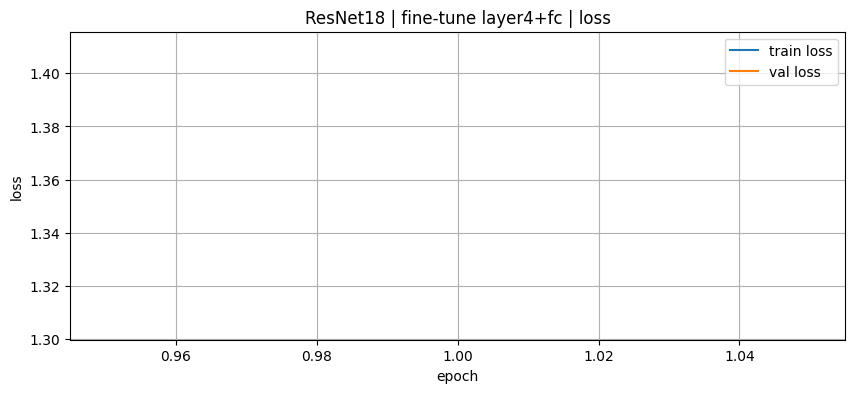

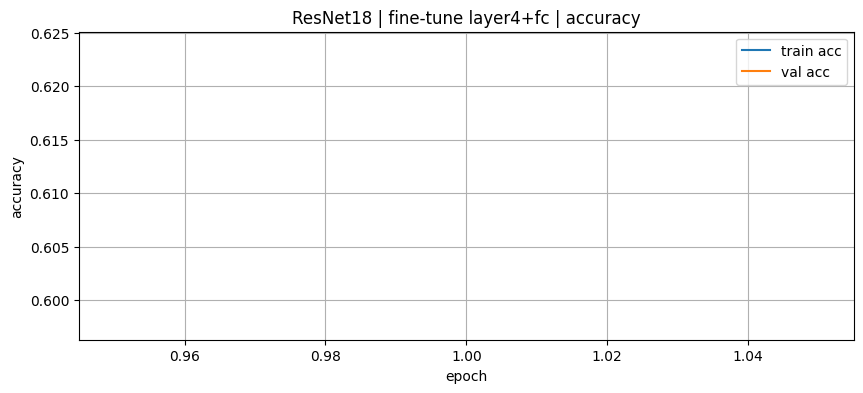

In [17]:
# размораживаем layer4 и fc
set_requires_grad(model_resnet18.layer4, True)
set_requires_grad(model_resnet18.fc, True)

params = [
    {"params": model_resnet18.layer4.parameters(), "lr": 1e-4},
    {"params": model_resnet18.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = run_experiment_resnet("C4", model_resnet18, optimizer_ft, epochs=1)
plot_history(hist_ft["history"], title="ResNet18 | fine-tune layer4+fc")

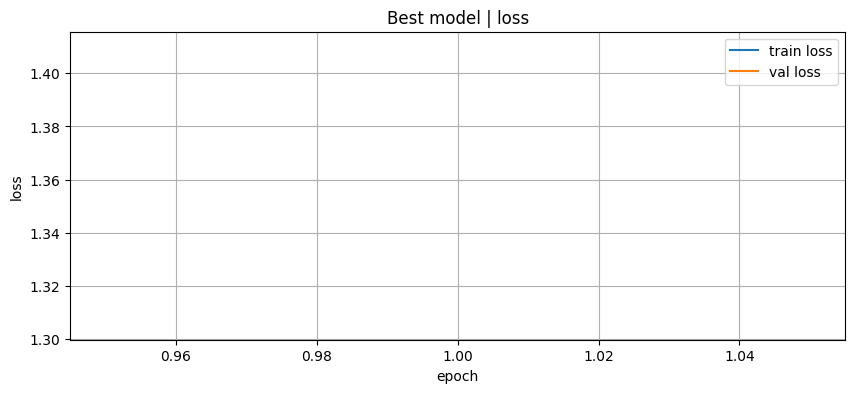

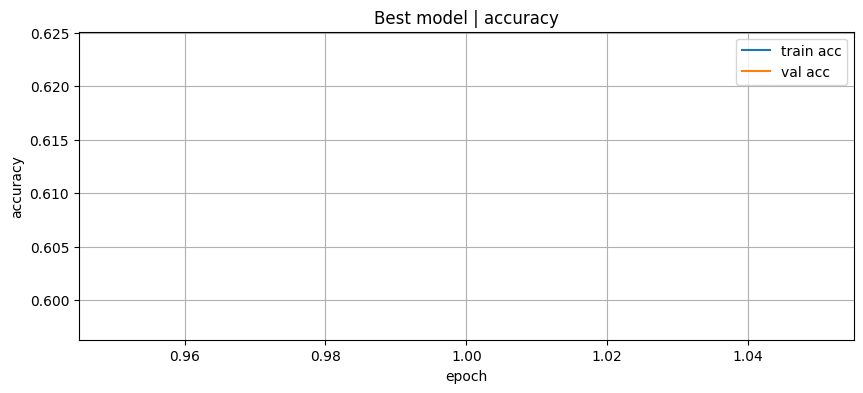

Test loss: 1.2943
Test accuracy: 0.6261


In [ ]:
# список всех созданных моделей
all_results = {
        'no_aug': res_no_aug,
        'aug': res_aug,
        'head': hist_head,
        'fine_tune': hist_ft,
    }

# выбор лучшей модели по val_acc
def get_best_model(all_results):
    best_result = max(all_results.values(), key=lambda x: max(x["history"]["val_acc"]))
    return best_result

# выдает данные об модели в формате json
def get_model_json(model, optimizer, dataset=DATASET_NAME, seed=RANDOM_STATE):
    opt_params = optimizer.param_groups[0]
    return {
        "dataset": dataset,
        "seed": seed,
        "fast_mode": FAST_MODE,
        "mean": CIFAR100_MEAN,
        "std": CIFAR100_STD,
        #"num_classes": model.num_classes,
        "exp": model["exp_id"],
        "optimizer": type(optimizer).__name__,
        "epochs": len(model["history"]["val_acc"]),
        "best_val_accuracy": float(np.max(model["history"]["val_acc"])),
        "best_val_loss": float(np.min(model["history"]["val_loss"]))
    }


best_model_cfg = get_best_model(all_results)
best_model = best_model_cfg["model"]
# сохранение графика лучшей модели
plot_history(best_model_cfg["history"], title="Best model", save_name = "classification_curves_best")

# тест прогон лучшей модели
test_loss, test_acc = evaluate(best_model, test_loader_resnet, criterion)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# сохранение best_model.pt
torch.save(best_model.state_dict(), os.path.join(ARTIFACTS_DIR, "best_classifier.pt"))

# сохранение best_config.json
best_config = get_model_json(best_model_cfg, optimizer_ft)
with open(os.path.join(ARTIFACTS_DIR, "best_classifier_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

In [ ]:
# сохранение данных об модели в массив runs
def save_results_runs(res_list, model, task, summary, optimizer, lr, epochs, notes,
                          dataset=DATASET_NAME, seed=RANDOM_STATE,
                          test_acc =None, test_loss=None):

    opt = type(model["history"]["optimizer"]).__name__, # вынимаем optimizer
    res_list.append({
        "experiment_id": model["exp_id"],
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": summary,
        "optimizer": opt,
        "lr": lr,
        "epochs_trained": len(model["history"]["val_acc"]),
        "best_val_accuracy": max(model["history"]["val_acc"]),
        "best_val_loss": min(model["history"]["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "precision": None,
        "recall": None,
        "mean_iou": None,
        "notes": notes,
    })


# сохранения в runs.csv
def save_runs_csv(res, path):
    df = pd.DataFrame(res)
    df.to_csv(path, index=False)
    print(f"Results saved to {path}")
    return df

runs = []

save_results_runs(
    runs, res_no_aug, "classification", "SimpleCNN no aug", "Adam", 0.001, EPOCHS_CNN, "Simple CNN without augmentations"
)

save_results_runs(
    runs, res_aug, "classification", "SimpleCNN with aug", "Adam", 0.001, EPOCHS_CNN, "Simple CNN with augmentations"
)

save_results_runs(
    runs, hist_head, "classification", "ResNet18 head-only", "Adam", 0.001, EPOCHS_HEAD, "Pretrained ResNet18 backbone frozen"
)

save_results_runs(
    runs, hist_ft, "classification", "ResNet18 fine-tune", "Adam", 0.0001, EPOCHS_FT,
    "Pretrained ResNet18 fine-tuning layer4 and fc", test_acc=test_acc, test_loss=test_loss,
)

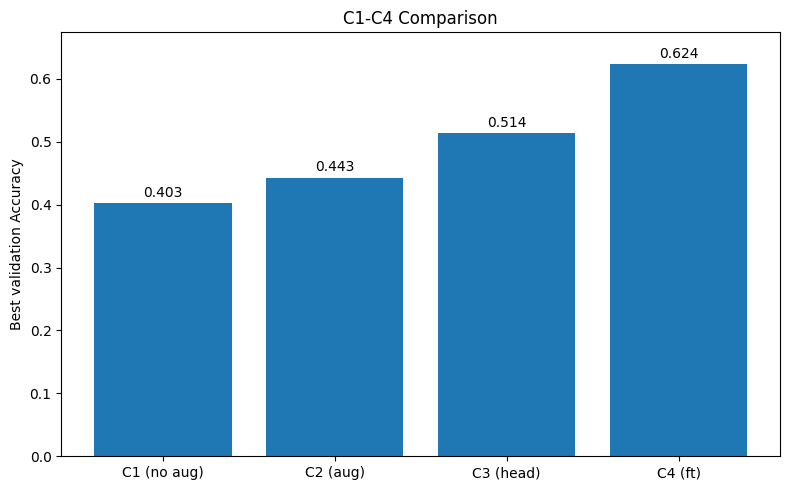

In [20]:
# построение графика сравнения метрик val_acc всех модеелей
exp_names = ["C1 (no aug)", "C2 (aug)", "C3 (head)", "C4 (ft)"]
best_accs = [
    max(res_no_aug["history"]["val_acc"]),
    max(res_aug["history"]["val_acc"]),
    max(hist_head["history"]["val_acc"]),
    max(hist_ft["history"]["val_acc"])
]

plt.figure(figsize=(8, 5))
bars = plt.bar(exp_names, best_accs)
plt.ylim(0, max(best_accs) + 0.05)
plt.ylabel("Best validation Accuracy")
plt.title("C1-C4 Comparison")

for bar, val in zip(bars, best_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "classification_compare.png"))
plt.show()

ЧАСТЬ B

In [21]:
import shutil
from dataclasses import dataclass
from torchvision.datasets.utils import download_and_extract_archive
from PIL import Image

# Конфигурация
@dataclass
class RunConfig:
    data_dir: str = DATA_DIR
    fast_mode: bool = True
    n_show: int = 3
    aeroplane_only: bool = True  # мы считаем IoU только по классу "aeroplane"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=3, aeroplane_only=True)

In [22]:
# Данные: Pascal VOC

VOC_URL = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

def ensure_pennfudan(root: str) -> str:
    voc_root = root + "/VOCdevkit/" + "VOC2012/"
    if os.path.isdir(voc_root):
        return voc_root

    os.makedirs(root, exist_ok=True)

    try:
        print("Downloading Pascal VOC to:", root)
        download_and_extract_archive(
            VOC_URL,
            download_root=root,
            filename="VOCtrainval_11-May-2012.tar",
            remove_finished=False
        )
        if not os.path.isdir(voc_root):
            raise FileNotFoundError("VOC2012 не найден после распаковки")
        return voc_root

    except Exception as e:
        print("Не удалось автоматически скачать датасет.")
        print("Ошибка:", repr(e))
        print("\nВариант вручную:")
        print(f"1) скачайте {VOC_URL}")
        print(f"2) распакуйте так, чтобы было: {voc_root}/JPEGImages и {voc_root}/SegmentationClass")
        raise

voc_root = ensure_pennfudan(cfg.data_dir)
voc_root

100.0%


'./data/VOCdevkit/VOC2012/'

In [23]:
# Dataset для сегментации

#import torch.utils.data

class VOCSegDataset(torch.utils.data.Dataset):
    def __init__(self, root: str):
        self.root = root
        self.img_dir = os.path.join(root, "JPEGImages")
        self.mask_dir = os.path.join(root, "SegmentationClass")

        split_file = os.path.join(root, "ImageSets", "Segmentation", "train.txt")

        with open(split_file) as f:
            self.ids = [line.strip() for line in f]

        self.imgs = [f"{id}.jpg" for id in self.ids]
        self.masks = [f"{id}.png" for id in self.ids]

        if len(self.imgs) == 0:# or len(self.imgs) != len(self.masks):
            raise RuntimeError("Похоже, структура VOC повреждена или не распакована полностью.")

    def __len__(self) -> int:
        return len(self.imgs)

    def __getitem__(self, idx: int):
        img_path = os.path.join(self.img_dir, self.imgs[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        if mask.size != img.size:
            mask = mask.resize(img.size, Image.NEAREST)

        mask_np = np.array(mask)
        mask_np[mask_np == 255] = 0
        gt = (mask_np == 1).astype(np.uint8)

        return img, gt  # img = PIL, gt = numpy

dataset = VOCSegDataset(voc_root)
len(dataset), dataset[0][0].size, dataset[0][1].shape

(1464, (500, 281), (281, 500))

In [24]:
# Модель: DeepLabV3 (COCO-with-VOC-labels) + поиск индекса класса "aeroplane"

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)

if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'aeroplane' динамически.")

if "aeroplane" not in categories:
    raise RuntimeError("В categories нет класса 'aeroplane'. Проверьте, какие веса вы загрузили.")

TARGET_IDX = categories.index("aeroplane")
print("num_classes:", len(categories))
print("TARGET_IDX:", TARGET_IDX)

# Трансформации, соответствующие обучению этих весов
preprocess = weights.transforms()
preprocess

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\User/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


num_classes: 21
TARGET_IDX: 1


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [27]:
# Инференс + IoU
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode
import cv2


@torch.no_grad()
def predict_target_mask(img_pil: Image.Image) -> torch.Tensor:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    target = (pred == int(TARGET_IDX)).to(torch.uint8)
    return target.cpu(), x.shape[-2:]  # (mask, (H,W))

def postprocess_v2(mask: torch.Tensor) -> torch.Tensor:
    mask_np = mask.numpy().astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_np, connectivity=8)

    new_mask = np.zeros_like(mask_np)

    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] > 300:
            new_mask[labels == i] = 1

    return torch.from_numpy(new_mask)

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def eval_subset(indices: List[int], use_v2: bool = False) -> Dict[str, float]:
    ious = []

    for idx in indices:
        img_pil, gt_np = dataset[idx]
        pred_mask, (h, w) = predict_target_mask(img_pil)

        if use_v2:
            pred_mask = postprocess_v2(pred_mask)

        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

def has_aeroplane(gt):
    return gt.sum() > 0

filtered_indices = []
for i in range(len(dataset)):
    _, gt = dataset[i]
    if has_aeroplane(gt):
        filtered_indices.append(i)

eval_indices = filtered_indices[:20]

In [28]:
metrics_v1 = eval_subset(eval_indices, use_v2=False)
print(metrics_v1)
metrics_v2 = eval_subset(eval_indices, use_v2=True)
print(metrics_v2)

{'n': 20.0, 'mean_IoU': 0.6909817119228159, 'median_IoU': 0.7753880816451562, 'min_IoU': 0.0, 'max_IoU': 0.9547278113813011}
{'n': 20.0, 'mean_IoU': 0.6907382612708503, 'median_IoU': 0.7753880816451562, 'min_IoU': 0.0, 'max_IoU': 0.9547278113813011}


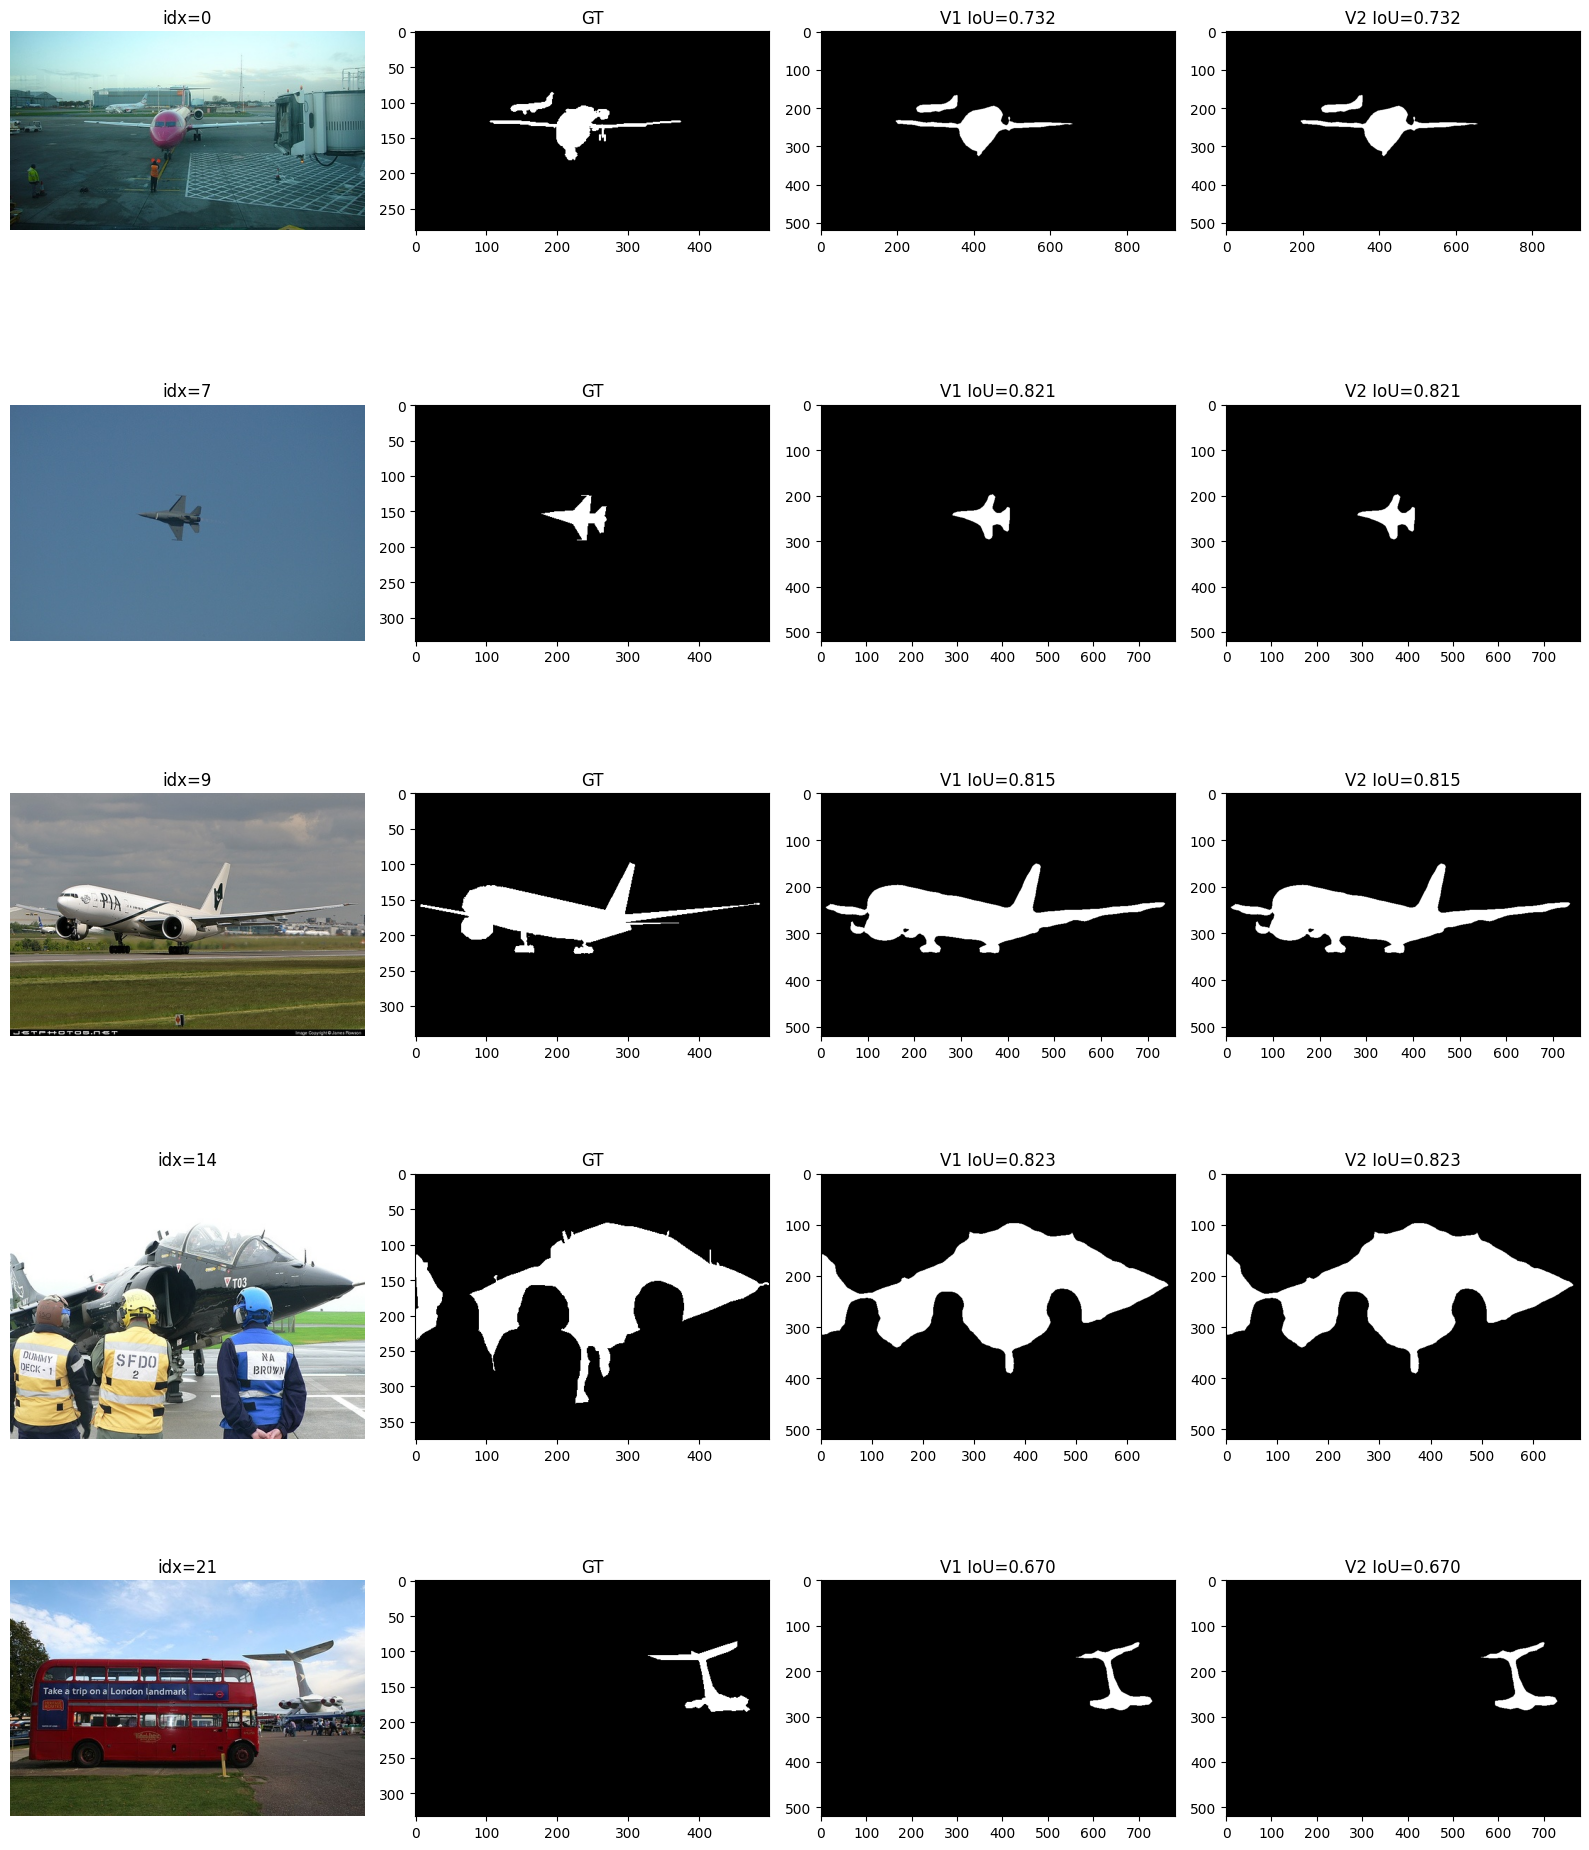

In [29]:
# Визуализация: image / GT / pred
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

n = min(5, len(dataset))
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    idx = filtered_indices[row]
    img_pil, gt_binary = dataset[idx]

    pred_v1, (h, w) = predict_target_mask(img_pil)
    pred_v2 = postprocess_v2(pred_v1)

    gt_pil = Image.fromarray((gt_binary * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou_v1 = iou_binary(pred_v1, gt_mask)
    iou_v2 = iou_binary(pred_v2, gt_mask)

    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"idx={idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_binary, cmap="gray")
    axes[row, 1].set_title("GT")

    axes[row, 2].imshow(pred_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 IoU={iou_v1:.3f}")

    axes[row, 3].imshow(pred_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 IoU={iou_v2:.3f}")

plt.tight_layout()
os.path.join(FIGURES_DIR, "segmentation_examples.png")
plt.savefig(os.path.join(FIGURES_DIR, "segmentation_examples.png"))
plt.show()

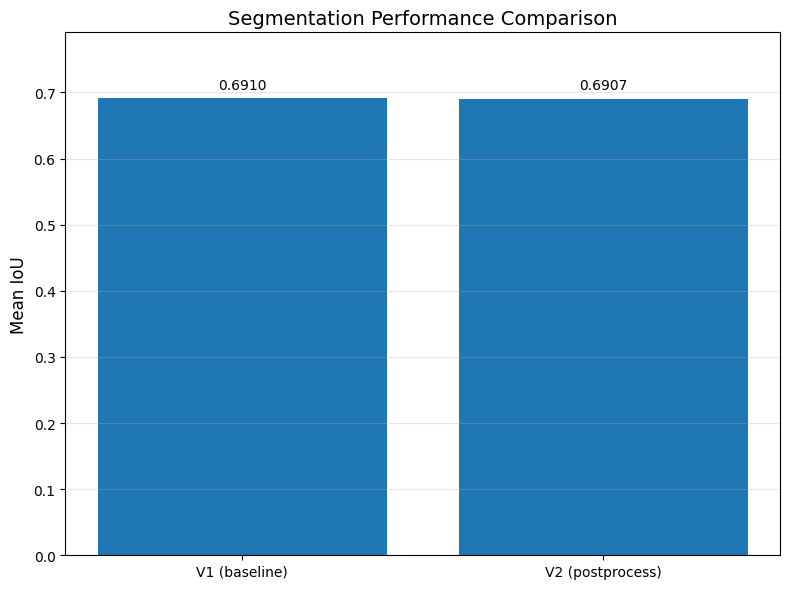

In [30]:
# построение графика V1 и V2 по Mean IoU

plt.figure(figsize=(8, 6))

methods = ['V1 (baseline)', 'V2 (postprocess)']
ious = [metrics_v1["mean_IoU"], metrics_v2["mean_IoU"]]

bars = plt.bar(methods, ious)

plt.ylabel('Mean IoU', fontsize=12)
plt.title('Segmentation Performance Comparison', fontsize=14)

plt.ylim(0, max(ious) + 0.1 if max(ious) > 0 else 1.0)

for bar, val in zip(bars, ious):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_DIR, "segmentation_metrics.png"))
plt.show()

In [31]:
# сохранение данных об модели (V1/V2) в массив
def save_results_runs(res_list, exp_id, task, dataset,
                      summary, mean_iou, notes,
                      seed = RANDOM_STATE):
    res_list.append({
        "experiment_id": exp_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "model_summary": summary,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_accuracy": None,
        "best_val_loss": None,
        "test_accuracy": None,
        "test_loss": None,
        "precision": None,
        "recall": None,
        "mean_iou": mean_iou,
        "notes": notes,
    })
    return res_list

In [32]:
save_results_runs(
    runs, "V1", "segmentation", "Pascal VOC",
    "DeepLabV3_ResNet50", f"{metrics_v1["mean_IoU"]:.6f}", "Baseline"
)

save_results_runs(
    runs, "V2", "segmentation", "Pascal VOC",
    "DeepLabV3_ResNet50", f"{metrics_v2["mean_IoU"]:.6f}", "Postprocess"
)

save_runs_csv(runs, os.path.join(ARTIFACTS_DIR, "runs.csv"))

Results saved to ./artifacts/runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,best_val_loss,test_accuracy,test_loss,precision,recall,mean_iou,notes
0,C1,classification,CIFAR100,42,SimpleCNN no aug,"(Adam,)",0.001,15.0,0.4029,2.382846,NaN,NaN,None,None,None,Simple CNN without augmentations
1,C2,classification,CIFAR100,42,SimpleCNN with aug,"(Adam,)",0.001,15.0,0.4430,2.114840,NaN,NaN,None,None,None,Simple CNN with augmentations
2,C3,classification,CIFAR100,42,ResNet18 head-only,"(Adam,)",0.001,1.0,0.5139,1.818379,NaN,NaN,None,None,None,Pretrained ResNet18 backbone frozen
3,C4,classification,CIFAR100,42,ResNet18 fine-tune,"(Adam,)",layer4:1e-4 fc:1e-3,1.0,0.6238,1.305105,0.6261,1.294264,None,None,None,Pretrained ResNet18 fine-tuning layer4 and fc
4,V1,segmentation,Pascal VOC,42,DeepLabV3_ResNet50,None,None,NaN,NaN,NaN,NaN,NaN,None,None,0.690982,Baseline
5,V2,segmentation,Pascal VOC,42,DeepLabV3_ResNet50,None,None,NaN,NaN,NaN,NaN,NaN,None,None,0.690738,Postprocess
